In [1]:
from src.object_funcs import no_object, object_phase_bar, object_absorbing_bar, object_two_absorbing_bars
from src.imaging_systems import Michaelson
from src.simulations import SPDC
from src.simulations import Imaging
from src.plotting_helpers import plot_visibility_images, plot_obj_plane, plot_visibility, plot_interf, analyze_psf

import numpy as np

In [2]:
# Parameters - nominal values are actually used in the experiment
# - crystal length
L_nominal = 2e-3 # m

# - crystal temperature
t_nominal = 25 # deg C

# - pump beam waist
omega_0_nominal = 750e-6 # m

# - pump power
P = 0.5 # W

# - ppKTP period
period = 9.325e-6 # m

# - pump wavelength
lambda_p = 532e-9 # m
lambda_s_degenerate = 1064e-9 #m

# - central signal wavelength
lambda_s_collinear = 873.76e-9

# - signal angles to be considered (this range covers entire detector plane
theta_s_min=0.0
theta_s_max=0.025

# Object
object_func = no_object

# Detector
detector_pixels = 31
detector_size = 3e-3

Signal batches:   0%|          | 0/1263 [00:00<?, ?it/s]

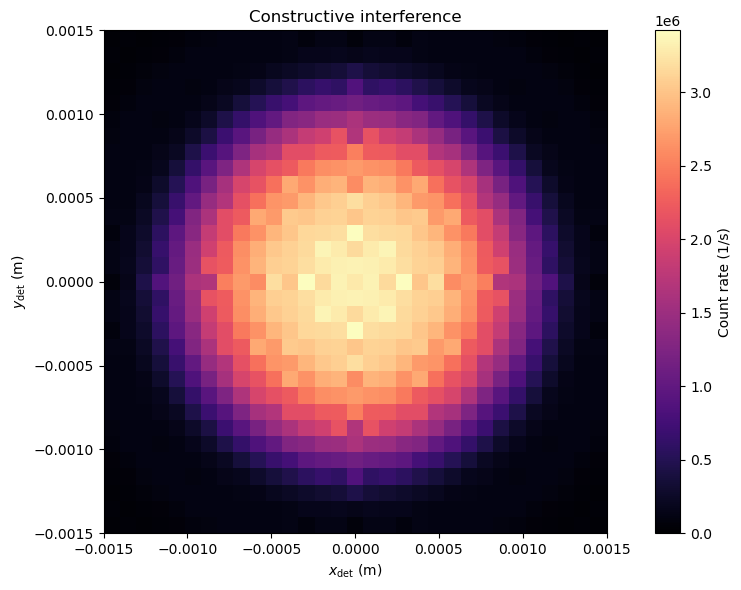

In [15]:
# Full simulation of SPDC signal central spot
lambda_s_min = lambda_s_collinear - 5.0e-9
lambda_s_max = lambda_s_collinear + 10e-9

spdc_inner_ring = SPDC(
    L=L_nominal,
    t=t_nominal,
    period=period,
    m=-1,
    chi_eff=6e-12,
    lambda_p=lambda_p,
    P=P,
    omega_0=omega_0_nominal,
    T_I=0,
    lambda_s_min=lambda_s_min,
    lambda_s_max=lambda_s_max,
    theta_s_min=theta_s_min,
    theta_s_max=theta_s_max,
    grid_size=201,
    N_phi=256,
    min_N_i=128,
    max_N_i=512,
    n_processes=9,
    signal_batch_size=32,
    seed=0,
)

imaging_system = Michaelson(source=spdc_inner_ring, f_i=0.2, f_d=0.15)

imaging = Imaging(
    source=spdc_inner_ring,
    imaging_system=imaging_system,
    detector_size=detector_size,
    detector_pixels=detector_pixels,
    object_func=object_func,
    signal_batch_size=32,
    n_processes=9,
    seed=0,
)

plus_image, minus_image, detector_visibility = imaging.full_simulation()
np.save("plus_image_inner_ring.npy", plus_image)
plot_interf(detector_size, detector_pixels, plus_image, interf_type="Constructive")

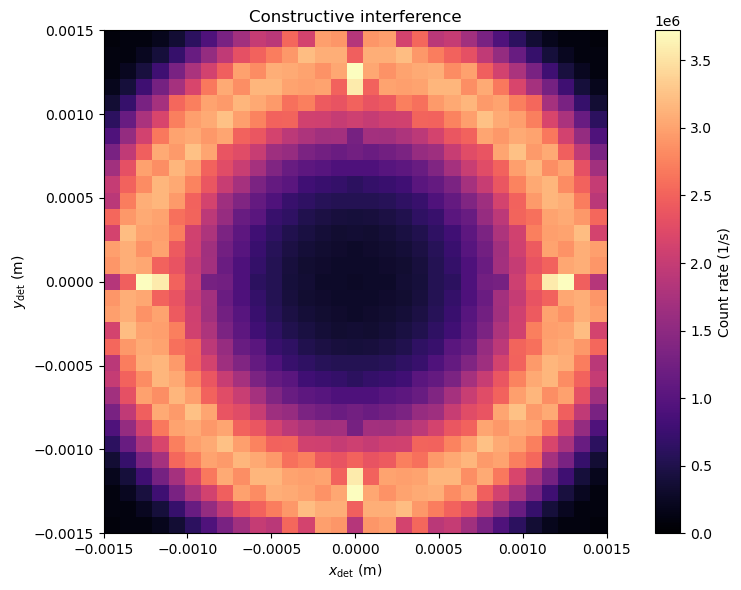

In [10]:
# Full simulation of SPDC signal ring
lambda_s_min = lambda_s_collinear - 15.0e-9
lambda_s_max = lambda_s_collinear - 5e-9

spdc_outer_ring = SPDC(
    L=L_nominal,
    t=t_nominal,
    period=period,
    m=-1,
    chi_eff=6e-12,
    lambda_p=lambda_p,
    P=P,
    omega_0=omega_0_nominal,
    T_I=0,
    lambda_s_min=lambda_s_min,
    lambda_s_max=lambda_s_max,
    theta_s_min=theta_s_min,
    theta_s_max=theta_s_max,
    grid_size=201,
    N_phi=256,
    min_N_i=128,
    max_N_i=512,
    n_processes=9,
    signal_batch_size=32,
    seed=0,
)

imaging_system = Michaelson(source=spdc_outer_ring, f_i=0.2, f_d=0.15)

imaging = Imaging(
    source=spdc_outer_ring,
    imaging_system=imaging_system,
    detector_size=detector_size,
    detector_pixels=detector_pixels,
    object_func=object_func,
    signal_batch_size=32,
    n_processes=9,
    seed=0,
)

plus_image, minus_image, detector_visibility = imaging.full_simulation()
np.save("plus_image_outer_ring.npy", plus_image)
plot_interf(detector_size, detector_pixels, plus_image, interf_type="Constructive")

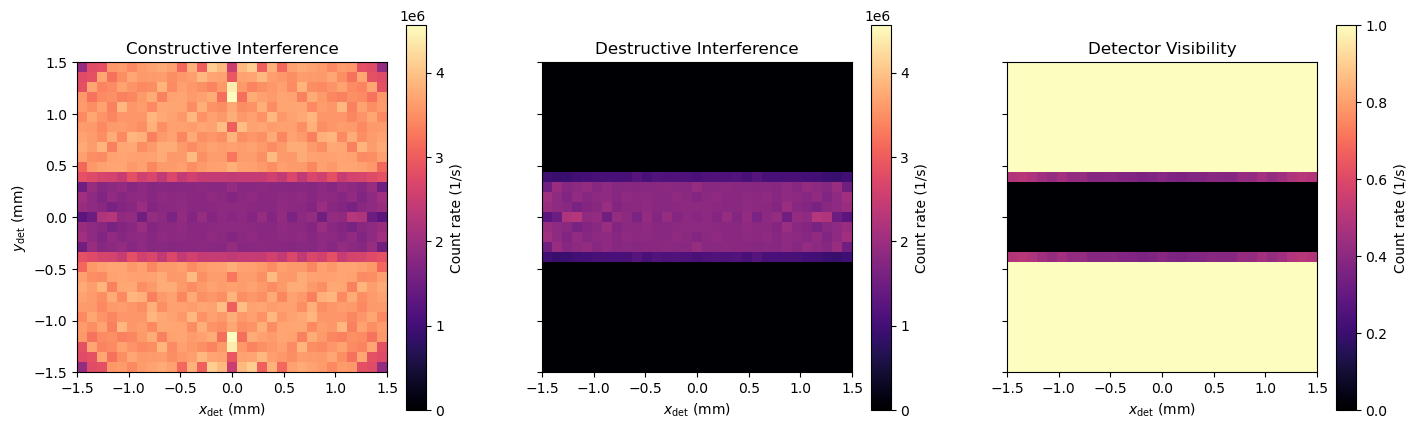

In [6]:
# Choose wide enough signal spot
lambda_s_min = lambda_s_collinear - 25e-9
lambda_s_max = lambda_s_collinear + 10e-9

# Note: This type of simulation is very computationally expensive
# 9 processes need about 2 hours to produce simulation results!
spdc_absorbing_bar = SPDC(
    L=L_nominal,
    t=t_nominal,
    period=period,
    m=-1,
    chi_eff=6e-12,
    lambda_p=lambda_p,
    P=P,
    omega_0=omega_0_nominal,
    T_I=0,
    lambda_s_min=lambda_s_min,
    lambda_s_max=lambda_s_max,
    theta_s_min=theta_s_min,
    theta_s_max=theta_s_max,
    grid_size=201,
    N_phi=256,
    min_N_i=128,
    max_N_i=512,
    n_processes=9,
    signal_batch_size=32,
    seed=0,
)

imaging_system = Michaelson(source=spdc_absorbing_bar, f_i=0.2, f_d=0.15)

# Test on simple absorbing object
object_func = object_two_absorbing_bars

imaging = Imaging(
    source=spdc_absorbing_bar,
    imaging_system=imaging_system,
    detector_size=detector_size,
    detector_pixels=detector_pixels,
    object_func=object_func,
    signal_batch_size=32,
    n_processes=9,
    seed=0,
)

# Get constructive and destructive interfrence on detector and calculate visibility
plus_image, minus_image, detector_visibility = imaging.full_simulation()
np.save("absorbing_bar_plus.npy", plus_image)
np.save("absorbing_bar_minus.npy", minus_image)
np.save("absorbing_bar_visibility.npy", detector_visibility)

plot_visibility_images(
    detector_size, detector_pixels,
    plus_image, minus_image, detector_visibility
)

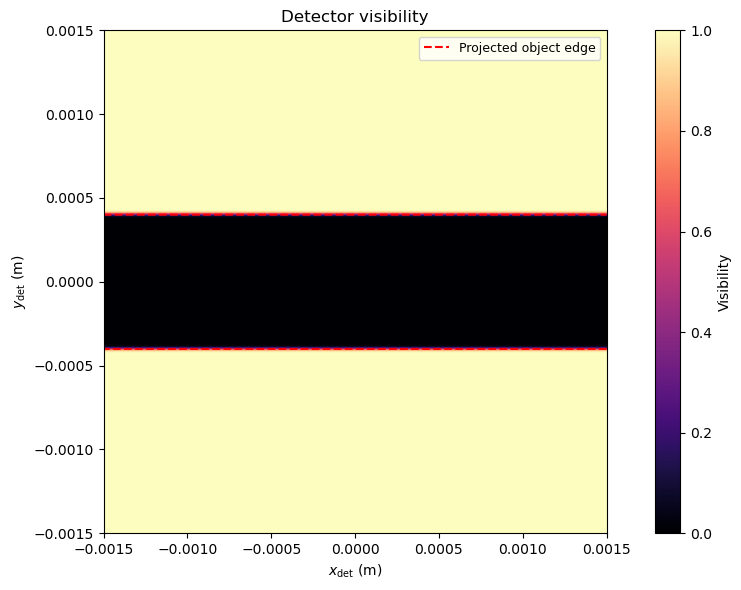

In [3]:
# Get visibility for the same object using convolution method
# Choose wide enough signal spot
lambda_s_min = lambda_s_collinear - 25e-9
lambda_s_max = lambda_s_collinear + 10e-9

# Note: This type of simulation is very computationaly expensive
# 9 processes need about 2 hours to produce simulation results!
spdc_absorbing_bar_fast = SPDC(
    L=L_nominal,
    t=t_nominal,
    period=period,
    m=-1,
    chi_eff=6e-12,
    lambda_p=lambda_p,
    P=P,
    omega_0=omega_0_nominal,
    T_I=0,
    lambda_s_min=lambda_s_min,
    lambda_s_max=lambda_s_max,
    theta_s_min=theta_s_min,
    theta_s_max=theta_s_max,
    grid_size=201,
    N_phi=256,
    min_N_i=128,
    max_N_i=512,
    n_processes=9,
    signal_batch_size=32,
    seed=0,
)

imaging_system = Michaelson(source=spdc_absorbing_bar_fast, f_i=0.2, f_d=0.15)

# Test on simple absorbing object
object_func = object_absorbing_bar

detector_pixels = 2001
imaging = Imaging(
    source=spdc_absorbing_bar_fast,
    imaging_system=imaging_system,
    detector_size=detector_size,
    detector_pixels=detector_pixels,
    object_func=object_func,
    signal_batch_size=32,
    n_processes=9,
    seed=0,
)

kernel = imaging.get_kernel()

visibility_object, details = (
    imaging.convolve_on_extended_object_plane(
        object_func=object_func,
        kernel=kernel,
        extension_factor=2,
        t_i=1.0,
    )
)

visibility_detector_convolution = (
    imaging.project_object_visibility_to_detector(
        visibility_object,
        magnification=imaging_system.magnification(),
    )
)

np.save("conv_sim_abs_bar_visibility.npy", visibility_detector_convolution)
plot_visibility(detector_size, 2001, visibility_detector_convolution, magnification=imaging_system.magnification(), overlay_object_contour=True, object_func=object_absorbing_bar)

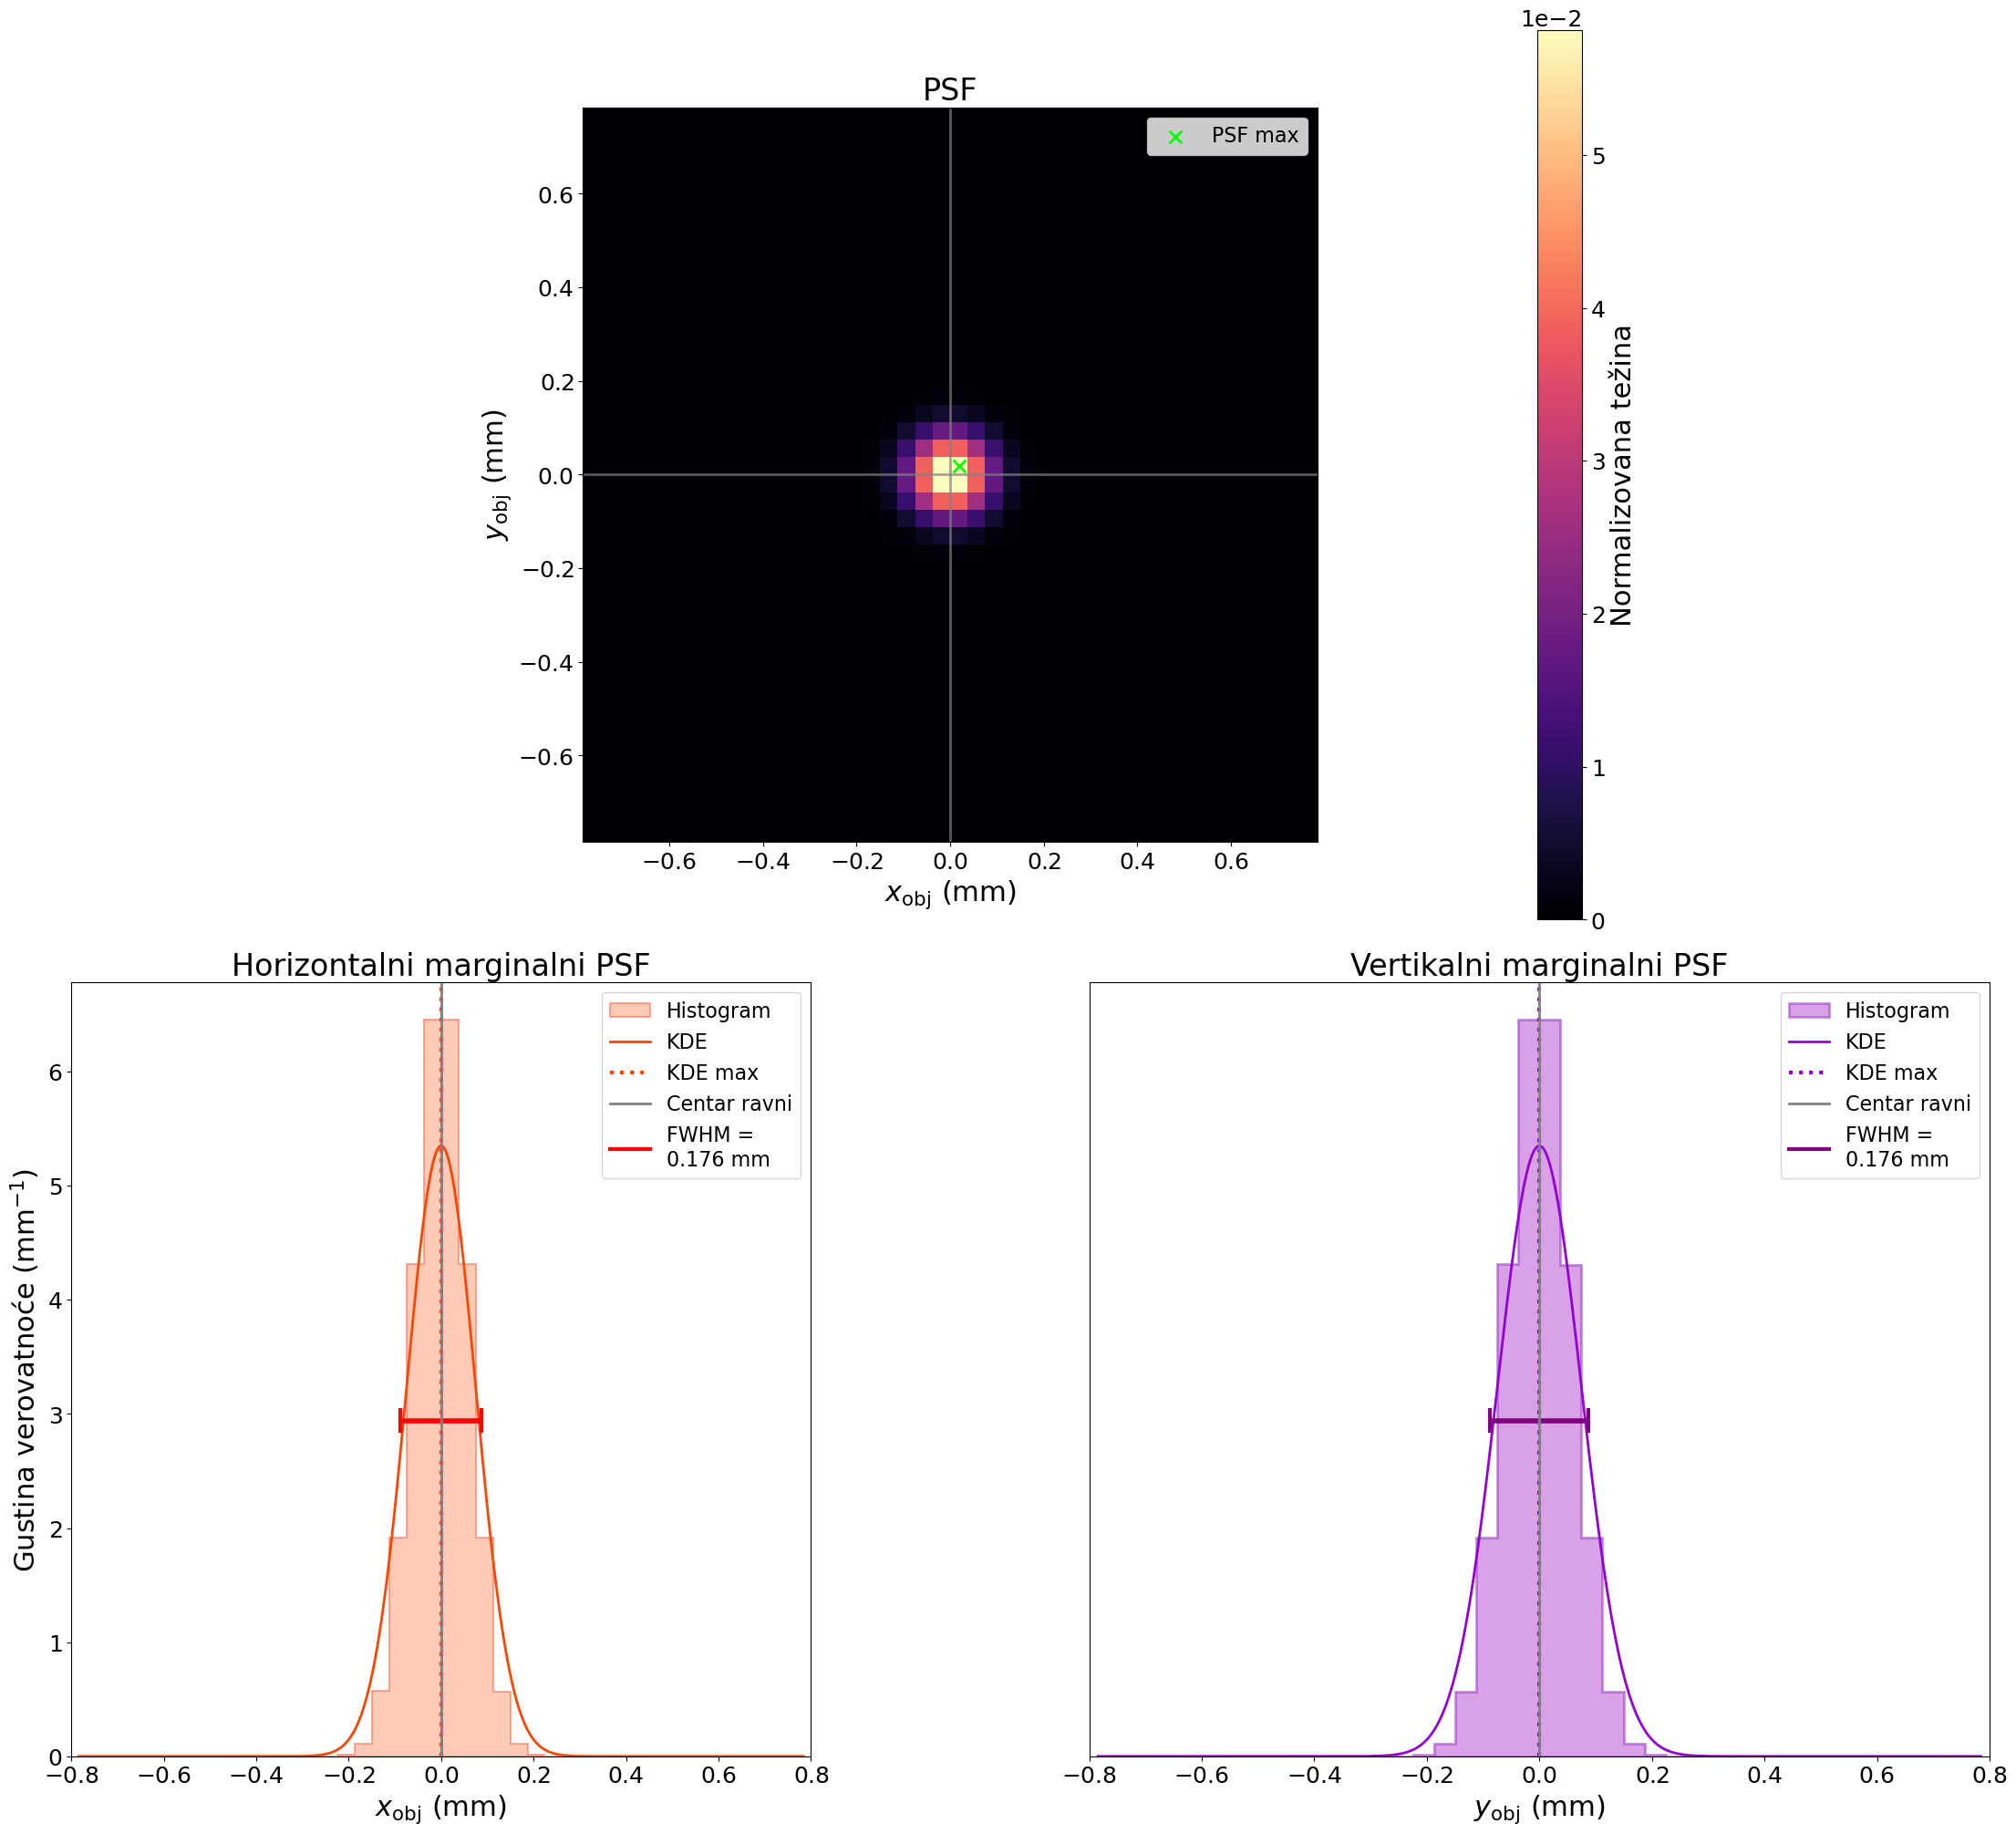

In [4]:
analyze_psf(
    psf=kernel,
    object_x_edges=imaging.object_x_edges,
    object_y_edges=imaging.object_y_edges,
    display_size=1.6e-3,
    normalize=True,
    normalize_display=True
)